<a href="https://colab.research.google.com/github/leshaz44/Aliaksei/blob/main/Task_6/Task_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Общая информация о датасете:
<class 'pandas.core.frame.DataFrame'>
Index: 6185 entries, 01/09/2000 to 29/04/2025
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   GC=F_closing_price  6185 non-null   float64
 1   Year                6185 non-null   object 
dtypes: float64(1), object(1)
memory usage: 145.0+ KB
None

Описание данных:
       GC=F_closing_price
count         6185.000000
mean          1184.765093
std            611.887867
min            255.100006
25%            636.700012
50%           1239.300049
75%           1642.099976
max           3406.199951

Количество пропусков:
GC=F_closing_price    0
Year                  0
dtype: int64


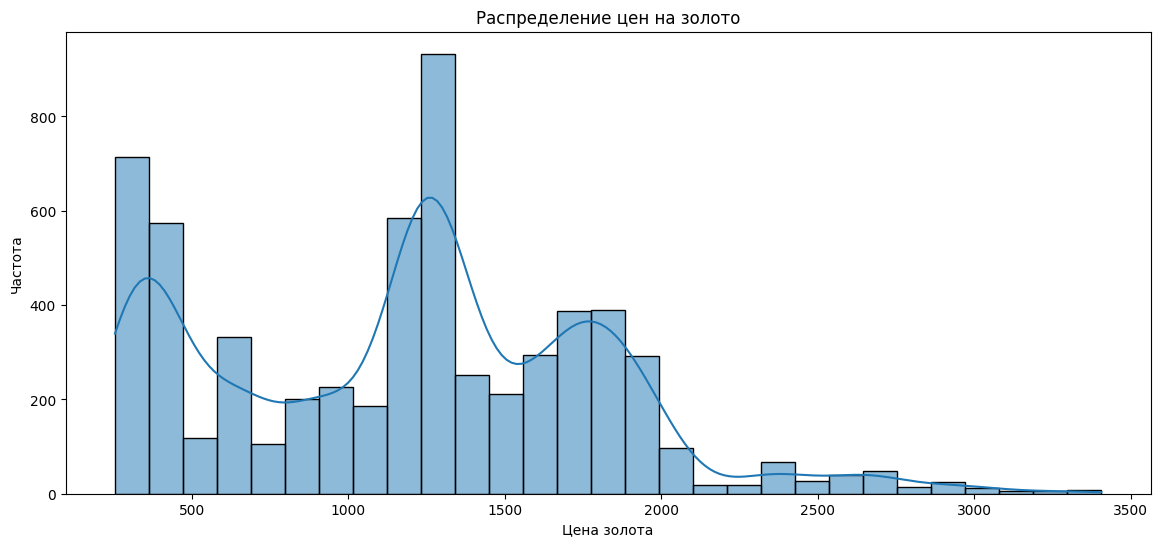

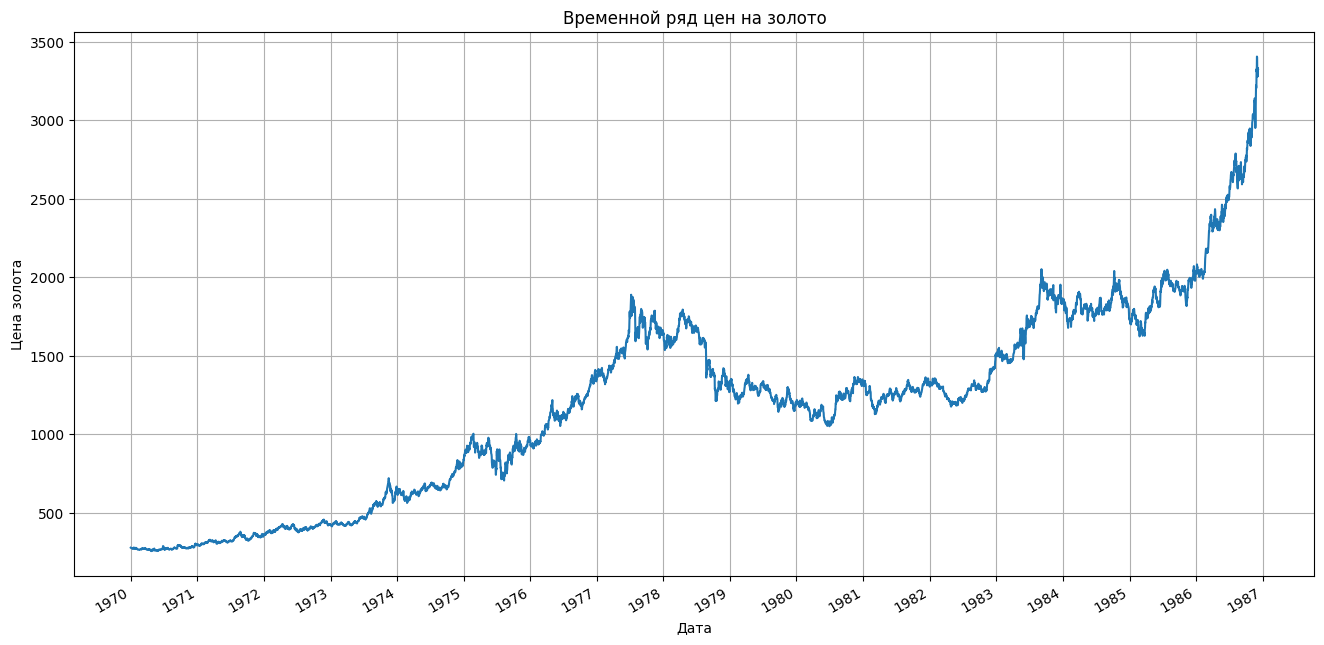

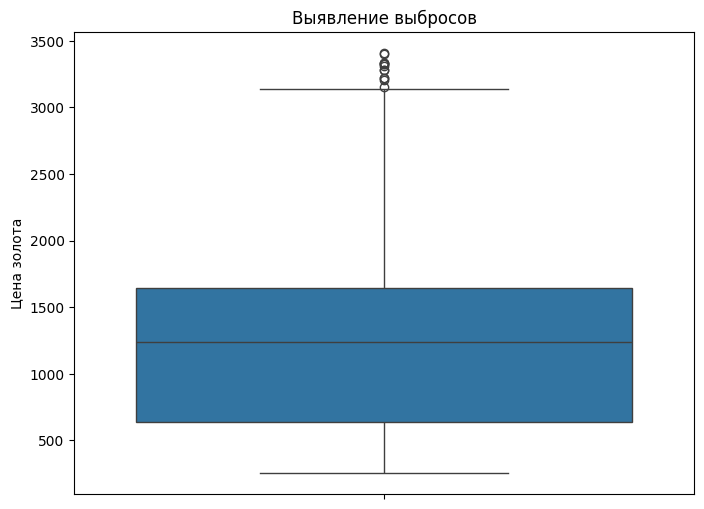

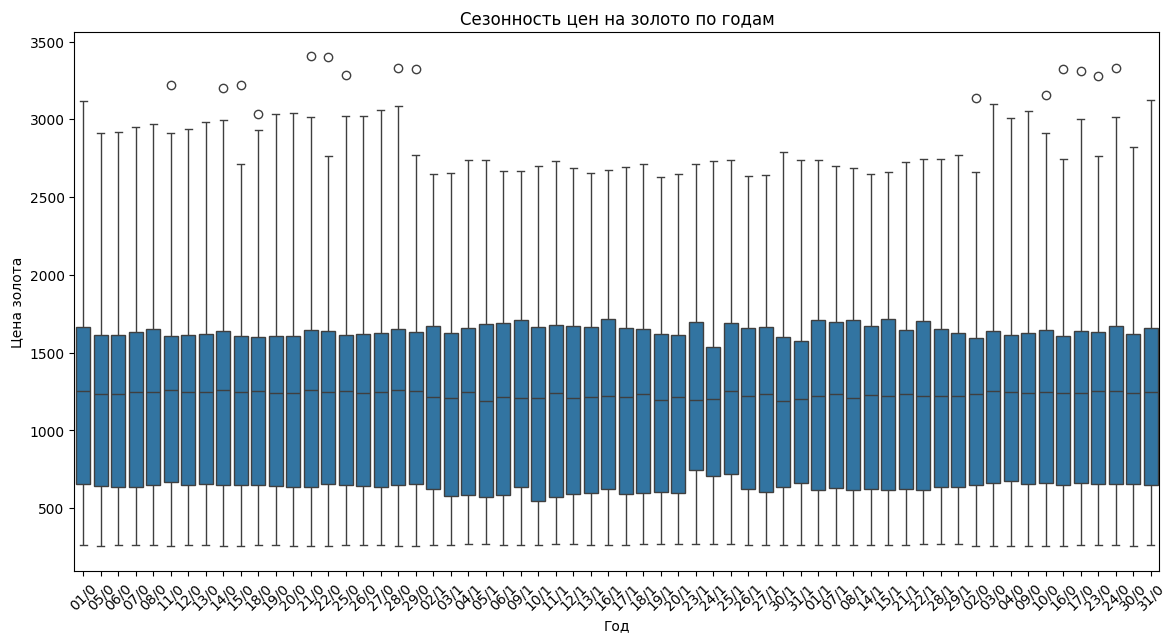

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
import matplotlib.dates as mdates

# Загрузка данных
df = pd.read_csv('Futures_Resources_Data.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)

# Выбираем только нужные столбцы
gold_data = df[['GC=F_closing_price']].dropna()

# Создаем столбец с годом через преобразование индекса в строку
gold_data['Year'] = gold_data.index.astype(str).str[:4]

# Альтернативный вариант через reset_index
# gold_data = df[['GC=F_closing_price']].dropna().reset_index()
# gold_data['Year'] = gold_data['Date'].dt.year

# Базовый обзор данных
print("Общая информация о датасете:")
print(gold_data.info())
print("\nОписание данных:")
print(gold_data.describe())

# Проверка на пропуски
print("\nКоличество пропусков:")
print(gold_data.isnull().sum())

# Распределение цены золота
plt.figure(figsize=(14, 6))
sns.histplot(gold_data['GC=F_closing_price'], kde=True)
plt.title('Распределение цен на золото')
plt.xlabel('Цена золота')
plt.ylabel('Частота')
plt.show()

# Временной ряд
plt.figure(figsize=(16, 8))
plt.plot(gold_data.index, gold_data['GC=F_closing_price'])
plt.title('Временной ряд цен на золото')
plt.xlabel('Дата')
plt.ylabel('Цена золота')
plt.grid(True)
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()
plt.show()

# Боксплот для выявления выбросов
plt.figure(figsize=(8, 6))
sns.boxplot(y=gold_data['GC=F_closing_price'])
plt.title('Выявление выбросов')
plt.ylabel('Цена золота')
plt.show()

# Анализ сезонности
plt.figure(figsize=(14, 7))
sns.boxplot(x='Year', y='GC=F_closing_price', data=gold_data)
plt.title('Сезонность цен на золото по годам')
plt.xlabel('Год')
plt.ylabel('Цена золота')
plt.xticks(rotation=45)
plt.show()


Training GRU model...
123/123 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - loss: 0.0040 - val_loss: 1.1124e-04

Training LSTM model...
123/123 ━━━━━━━━━━━━━━━━━━━━ 12s 70ms/step - loss: 0.0040 - val_loss: 7.6373e-05

Training RNN model...
123/123 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 0.0390 - val_loss: 5.1896e-04

Training CNN model...
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0021 - val_loss: 2.9403e-04

Training Autoencoder model...
123/123 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0024 - val_loss: 2.5173e-04

Оцениваем модель GRU...
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step

Оцениваем модель LSTM...
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step

Оцениваем модель RNN...
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

Оцениваем модель CNN...
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Оцениваем модель Autoencoder...
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

Результаты для модели GRU:
RMSE: 62.75
MAE: 52.30
R2: 0.9685
MAPE: 2.49%


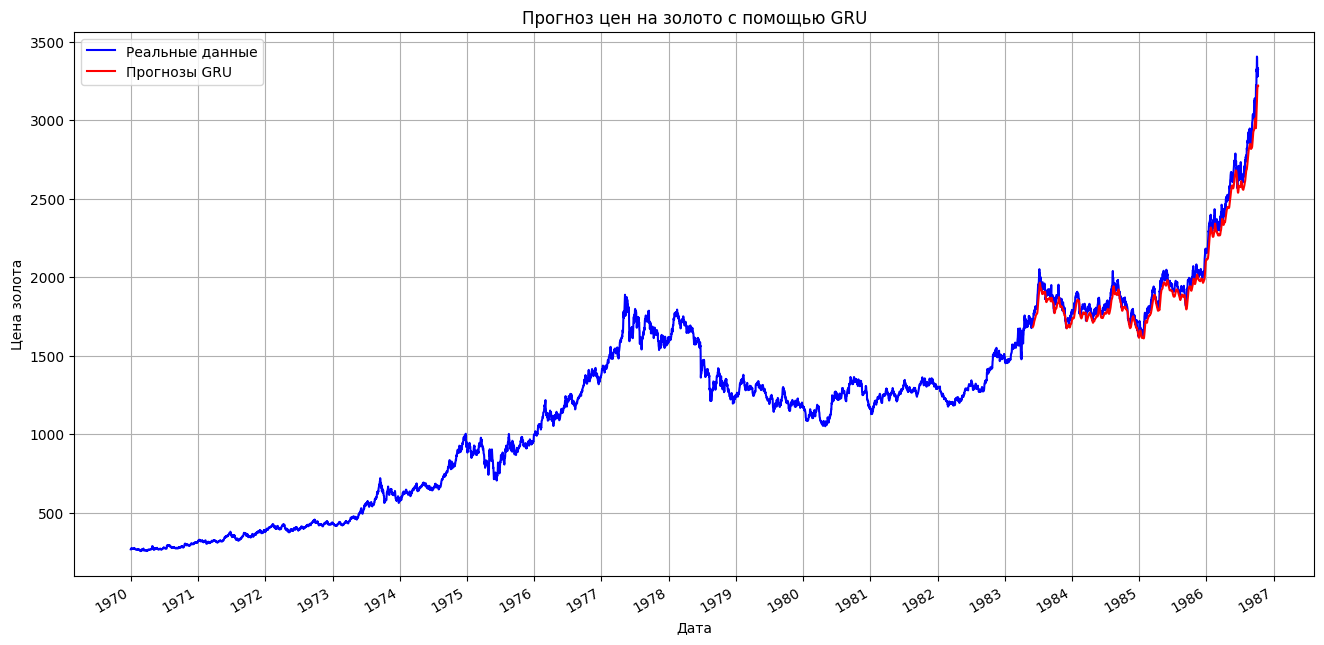


Результаты для модели LSTM:
RMSE: 49.47
MAE: 36.68
R2: 0.9804
MAPE: 1.76%


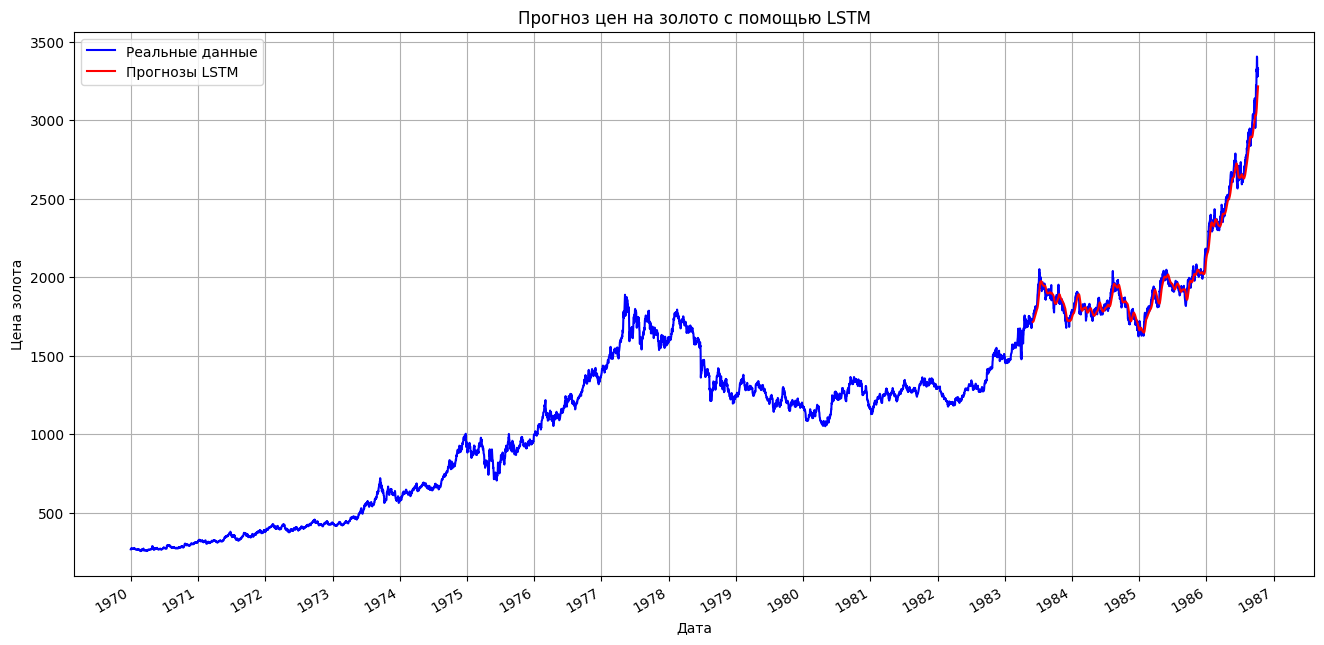


Результаты для модели RNN:
RMSE: 206.04
MAE: 173.89
R2: 0.6604
MAPE: 8.05%


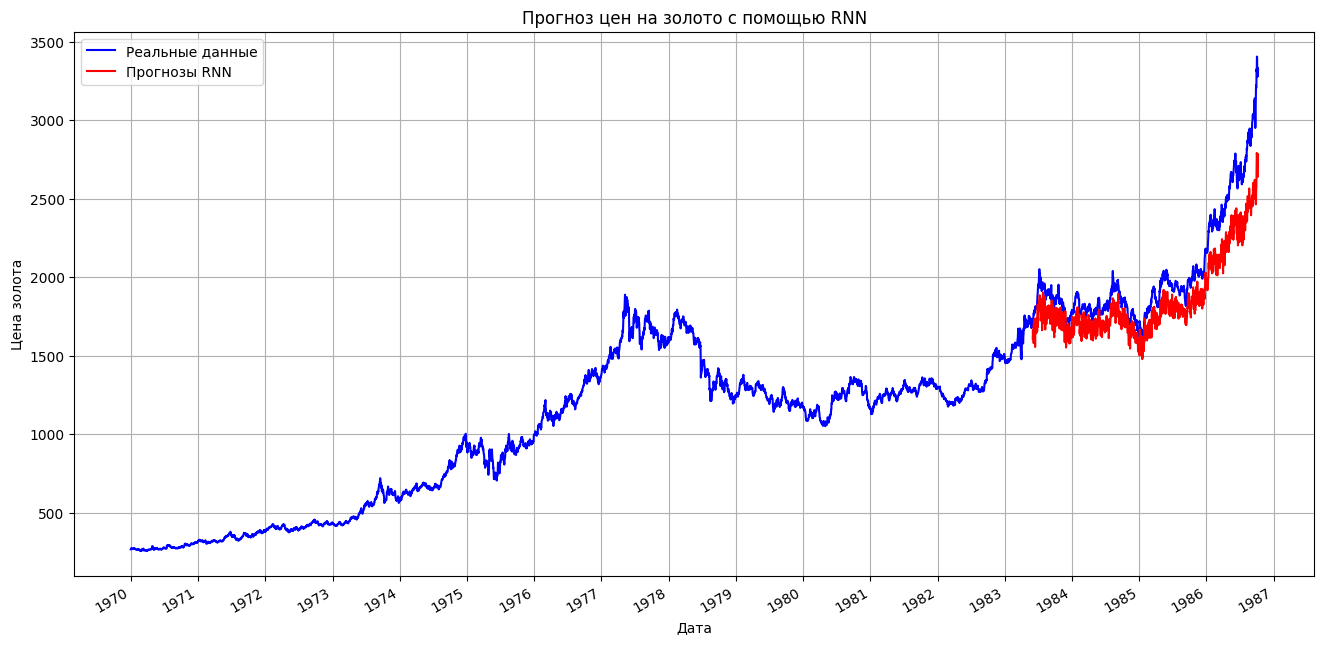


Результаты для модели CNN:
RMSE: 95.31
MAE: 71.07
R2: 0.9273
MAPE: 3.31%


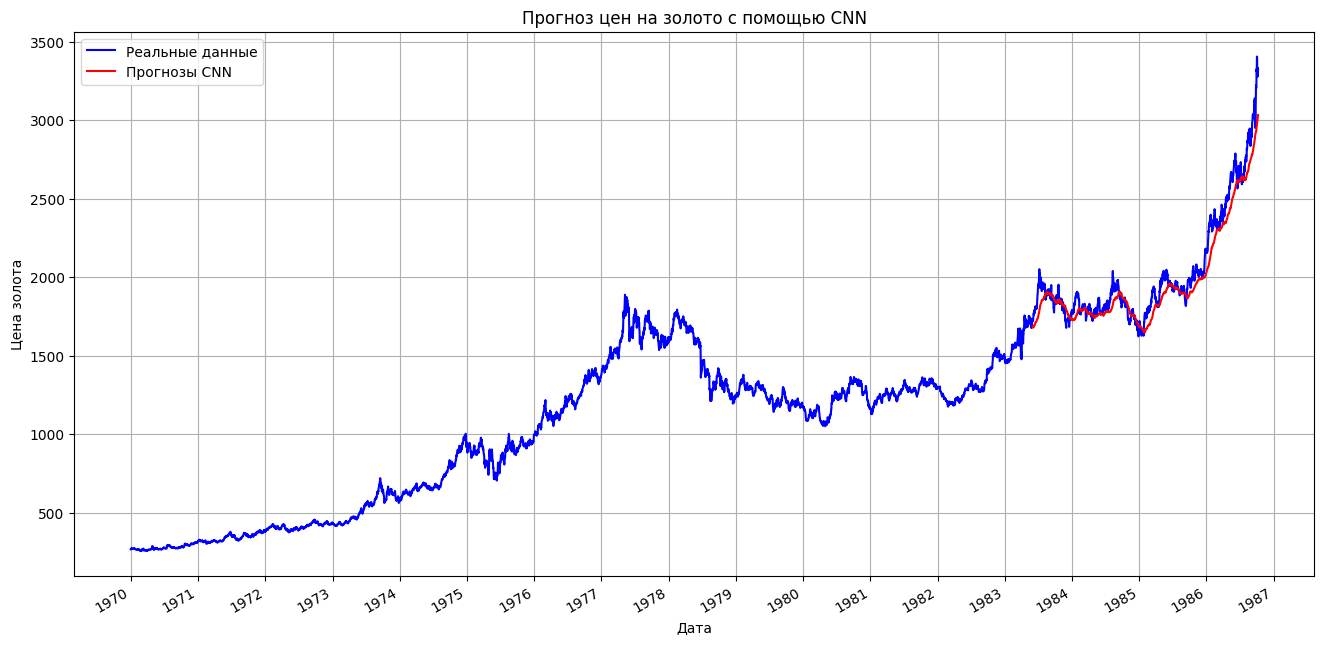


Результаты для модели Autoencoder:
RMSE: 104.99
MAE: 77.41
R2: 0.9118
MAPE: 3.58%


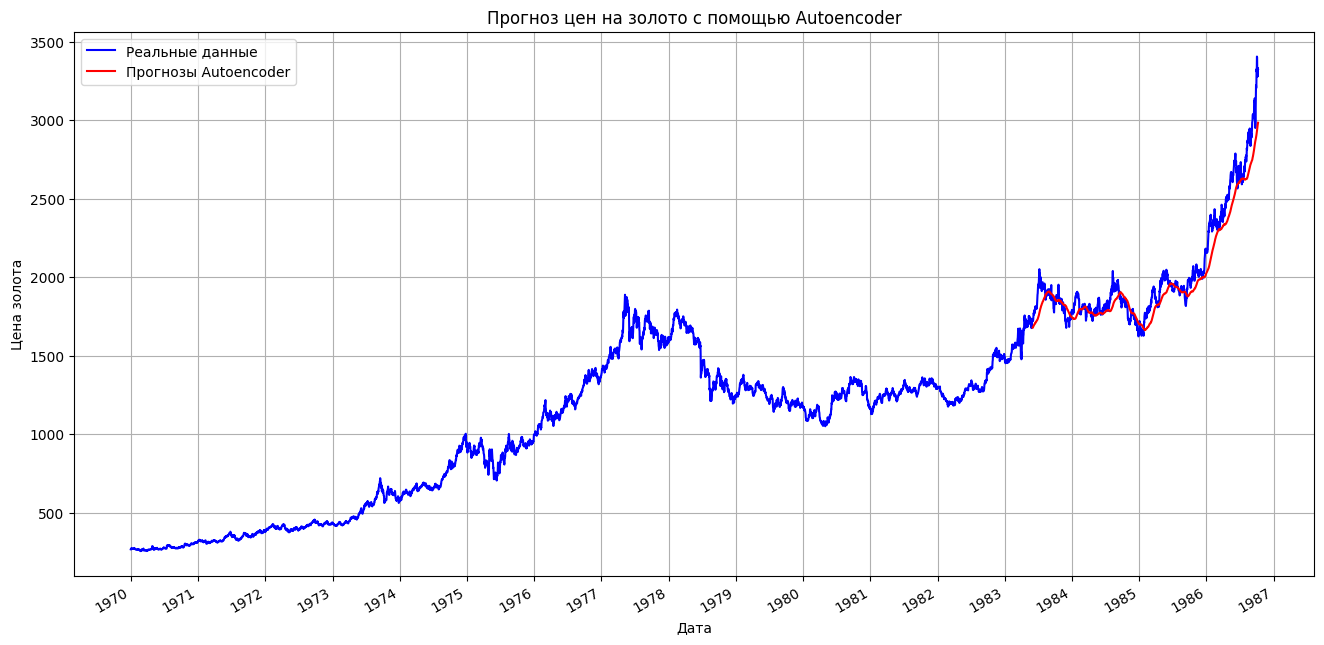

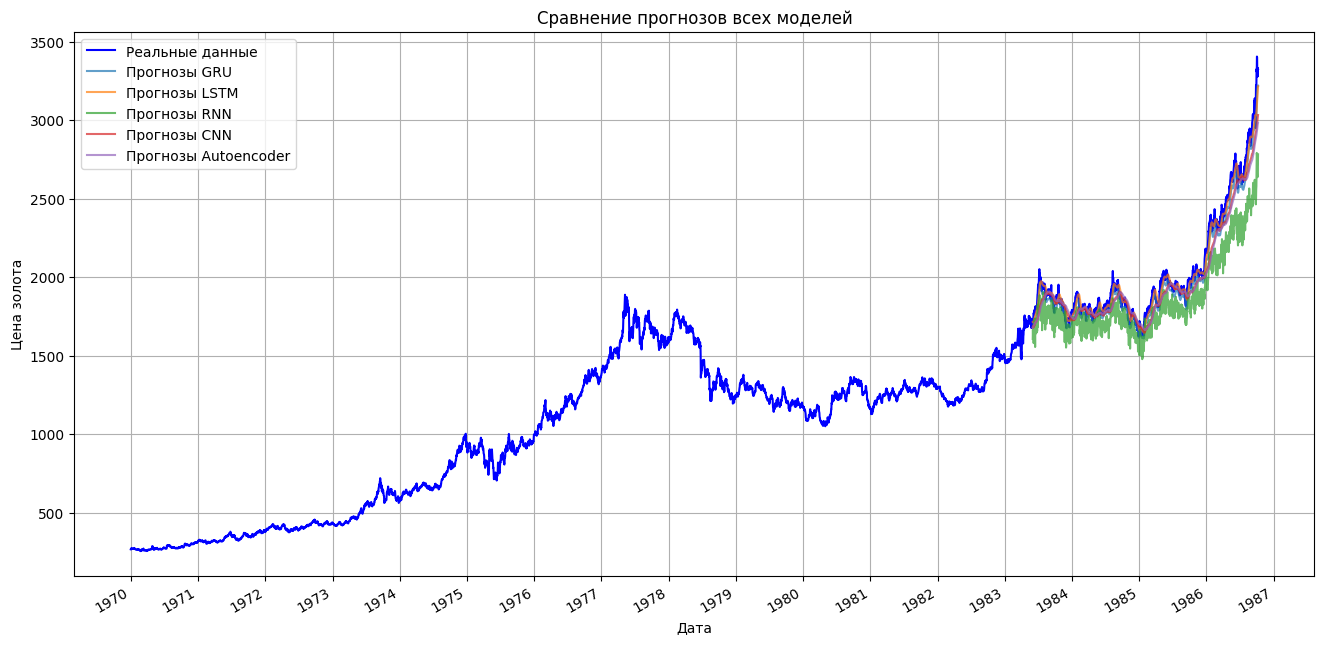


Сравнение метрик моделей:
        Модель        RMSE         MAE        R2      MAPE
0          GRU   62.754563   52.300237  0.968491  2.487511
1         LSTM   49.468792   36.676884  0.980420  1.755892
2          RNN  206.035402  173.894108  0.660355  8.051025
3          CNN   95.306610   71.072353  0.927325  3.307080
4  Autoencoder  104.993167   77.407299  0.911801  3.582306


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    GRU, LSTM, SimpleRNN, Dense, Dropout, Input,
    Conv1D, MaxPooling1D, Flatten
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import matplotlib.dates as mdates
from tensorflow.keras.callbacks import EarlyStopping

# Загрузка данных
df = pd.read_csv('Futures_Resources_Data.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)

# Выбираем только данные по золоту
gold_data = df['GC=F_closing_price'].dropna()

# Нормализация данных
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(gold_data.values.reshape(-1,1))

# Создание обучающих последовательностей
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:(i+seq_length)])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

sequence_length = 60
X, y = create_sequences(scaled_data, sequence_length)

# Разделение на выборки
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Функция для построения моделей
def build_model(model_type):
    input_layer = Input(batch_shape=(None, X_train.shape[1], 1))

    if model_type == 'GRU':
        x = GRU(50, return_sequences=True)(input_layer)
        x = Dropout(0.2)(x)
        x = GRU(50, return_sequences=False)(x)

    elif model_type == 'LSTM':
        x = LSTM(50, return_sequences=True)(input_layer)
        x = Dropout(0.2)(x)
        x = LSTM(50, return_sequences=False)(x)

    elif model_type == 'RNN':
        x = SimpleRNN(50, return_sequences=True)(input_layer)
        x = Dropout(0.2)(x)
        x = SimpleRNN(50, return_sequences=False)(x)

    elif model_type == 'CNN':
        x = Conv1D(filters=64, kernel_size=3, activation='relu')(input_layer)
        x = MaxPooling1D(pool_size=2)(x)
        x = Flatten()(x)

    elif model_type == 'Autoencoder':
        # Encoder часть
        x = Dense(128, activation='relu')(input_layer)
        x = Dense(64, activation='relu')(x)

        # Bottleneck
        encoded = Dense(32, activation='relu')(x)

        # Decoder часть
        x = Dense(64, activation='relu')(encoded)
        x = Dense(128, activation='relu')(x)

        # Выходной слой
        x = Flatten()(x)

    x = Dropout(0.2)(x)
    output_layer = Dense(units=1)(x)

    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Обучение моделей
models = {}
results = {}

for model_type in ['GRU', 'LSTM', 'RNN', 'CNN', 'Autoencoder']:
    print(f"\nTraining {model_type} model...")

    # Создаем модель
    model = build_model(model_type)
    models[model_type] = model

    # Добавляем Early Stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Обучаем модель
    history = model.fit(
        X_train, y_train,
        epochs=1,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1
    )

    # Сохраняем историю обучения
    results[model_type] = {
        'history': history,
        'model': model
    }

# Функция для оценки моделей
def evaluate_model(model, X_test, y_test, scaler):
    # Прогнозирование
    test_predict = model.predict(X_test)

    # Обратное преобразование масштабирования
    test_predict = scaler.inverse_transform(test_predict)
    y_true = scaler.inverse_transform(y_test.reshape(-1,1))

    # Метрики
    rmse = np.sqrt(mean_squared_error(y_true, test_predict))
    mae = mean_absolute_error(y_true, test_predict)
    r2 = r2_score(y_true, test_predict)
    mape = mean_absolute_percentage_error(y_true, test_predict) * 100

    return {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'MAPE': mape,
        'predictions': test_predict
    }

# Оценка всех моделей
evaluation_results = {}

for model_type in models:
    print(f"\nОцениваем модель {model_type}...")
    evaluation_results[model_type] = evaluate_model(
        models[model_type],
        X_test,
        y_test,
        scaler
    )

# Визуализация результатов
def plot_results(model_type):
    plt.figure(figsize=(16, 8))
    plt.plot(gold_data.index[sequence_length:],
             scaler.inverse_transform(y.reshape(-1,1)),
             label='Реальные данные', color='blue')

    plt.plot(gold_data.index[-len(evaluation_results[model_type]['predictions']):],
             evaluation_results[model_type]['predictions'],
             label=f'Прогнозы {model_type}', color='red')

    plt.title(f'Прогноз цен на золото с помощью {model_type}')
    plt.xlabel('Дата')
    plt.ylabel('Цена золота')
    plt.legend()
    plt.grid(True)
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.gcf().autofmt_xdate()
    plt.show()

# Визуализация ошибок
def plot_error_comparison():
    plt.figure(figsize=(14, 7))
    for model_type in evaluation_results:
        errors = evaluation_results[model_type]['predictions'] - scaler.inverse_transform(y_test.reshape(-1,1))
        plt.plot(
            gold_data.index[-len(errors):],
            errors.flatten(),
            label=model_type
        )
    plt.axhline(y=0, color='black', linestyle='--')
    plt.title('Сравнение ошибок моделей')
    plt.xlabel('Дата')
    plt.ylabel('Ошибка прогноза')
    plt.legend()
    plt.grid(True)
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.gcf().autofmt_xdate()
    plt.show()

# Визуализация всех моделей
for model_type in models:
    print(f"\nРезультаты для модели {model_type}:")
    print(f"RMSE: {evaluation_results[model_type]['RMSE']:.2f}")
    print(f"MAE: {evaluation_results[model_type]['MAE']:.2f}")
    print(f"R2: {evaluation_results[model_type]['R2']:.4f}")
    print(f"MAPE: {evaluation_results[model_type]['MAPE']:.2f}%")
    plot_results(model_type)

# Дополнительная визуализация - сравнение прогнозов
plt.figure(figsize=(16, 8))
plt.plot(
    gold_data.index[sequence_length:],
    scaler.inverse_transform(y.reshape(-1,1)),
    label='Реальные данные',
    color='blue'
)

for model_type in evaluation_results:
    plt.plot(
        gold_data.index[-len(evaluation_results[model_type]['predictions']):],
        evaluation_results[model_type]['predictions'],
        label=f'Прогнозы {model_type}',
        alpha=0.7
    )

plt.title('Сравнение прогнозов всех моделей')
plt.xlabel('Дата')
plt.ylabel('Цена золота')
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()
plt.show()

# Сравнение метрик
comparison_df = pd.DataFrame({
    'Модель': list(evaluation_results.keys()),
    'RMSE': [res['RMSE'] for res in evaluation_results.values()],
    'MAE': [res['MAE'] for res in evaluation_results.values()],
    'R2': [res['R2'] for res in evaluation_results.values()],
    'MAPE': [res['MAPE'] for res in evaluation_results.values()]
})

print("\nСравнение метрик моделей:")
print(comparison_df)